In [108]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [109]:
import numpy as np
import matplotlib.pyplot as plt
from cvx_opt.hw6 import load_data, prox_gradient_descent, Model, nelder_mead, ZeroCost
from cvx_opt.functions import LogLikelihoodLogistic as LL

# Problem 1

Below, we solve the spam problem using a variety of solvers, including:
1. Gradient descent solver from hw6
2. a newly implemented proximal gradient descent solver which includes Nestorov acceleration, as detailed on page 23 of Beck and Teboulle's gradient-based algorithms [chapter](https://www.math.tau.ac.il/~teboulle/papers/gradient_chapter.pdf).
4. the Nelder-Mead solver implemented by scipy.optimize.fmin

Note that most of the implementation is stored in python modules outside this notebook. Note, the proximal gradient algorithm reduces to gradient descent when taking `g` to be `0`.

First, we include a check to gain confidence that our proximal gradient descent algorithm behaves as intended:

## Preliminary implementation Check
To gain confidence that our proximal gradient descent implementation is correct, we test on a simple quadratic cost function.


In [110]:
class QuadraticCost:
    """Implement a simple quadratic cost 1/2||Ax - b||_2^2 (taking A as the identity) and its gradient."""
    def __init__(self, b):
        self.b = b
        
    def f(self, x):
        return 1/2 * np.linalg.norm(x - self.b)**2

    def grad(self, x):
        return x - self.b
        

In [111]:
x0 = np.zeros(4)
b = np.array([1, 2, 3, 4])
cost = QuadraticCost(b)
res = prox_gradient_descent(cost, x0, stepsize=1e-2)
print(res)

SolverResult:
    Converged=True
    iterations=460
    function_eval=1.1714498708873564e-07



In [112]:
# Assert that we approach the correct solution (at least approximately)
assert  np.linalg.norm(res.solution - b) < 1e-3

## Load data and run optimizers
The code below loads the spam data and trains on a subset of the dataset. (Note, the details of training versus testing split are encapsulated by the Dataset and Model objects and thus occurs behind the scenes.)

In [6]:
# Load the Spam dataset from disk
N_train = 3096
dataset = load_data(N_train)

In [7]:
options = {
    "stepsize": 1e-5,
    "maxiters": 10_000,
    "tol": 1e-3
}

m = Model(LL, solver_options=options)

In [8]:
m.train(dataset)

SolverResult:
    Converged=True
    iterations=734
    function_eval=499.0440333086468

In [9]:
options = {
    "stepsize": 1e-5,
    "maxiters": 100_000,
    "tol": 1e-3
}
m_accel = Model(LL, solver=prox_gradient_descent, solver_options=options)

In [10]:
m_accel.train(dataset)

SolverResult:
    Converged=True
    iterations=854
    function_eval=451.01357259083113

In [11]:
nelder_opts = {
    "maxiter": 100_000,
    "xtol":1e-3
}
m_nelder = Model(LL, nelder_mead, solver_options=nelder_opts)

In [12]:
m_nelder.train(dataset)

Optimization terminated successfully.
         Current function value: 542.506465
         Iterations: 42251
         Function evaluations: 46660


SolverResult:
    Converged=True
    iterations=42252
    function_eval=542.5064649376845

In [13]:
def comparison_plot(k_max=None):
    plt.figure()
    for model, label in zip([m, m_accel, m_nelder], 
                             ["Gradient Descent", "Nestorov-accelerated Descent", "Nelder-Mead"]):
        plt.plot(model.result.costs, label=label)
    plt.legend()
    
    plt.xlabel("Iteration")
    plt.ylabel("Cost Evaluation")
    plt.title("Comparison of solution methods for Spam Detection Problem")
    # plt.xlim([0, 30])
    if k_max is not None:
        plt.xlim([1, k_max])

## Comparison of objective function over across solution methods

Plots which compare the methods are shown below.

The most immediate observation is that Nelder-Mead takes a significantly longer time to converge than
either gradient descent or its Nestorov-accelerated version. It is also not particularly continuous in its rate of descent. It has periods when the rate slows dramatically (w.r.t. solver iteration), resulting in concave sections of the curve.

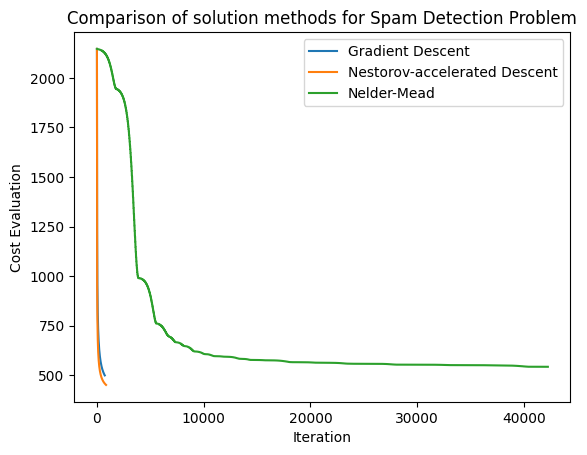

In [14]:
comparison_plot()

We zoom in further to compare the vanilla gradient descent (GD) and Nestorov-accelerated gradient descent (NAGD) more closely. We see the 
acceleartion indeed causes the algorithm to converge faster and to a lower objective value. 

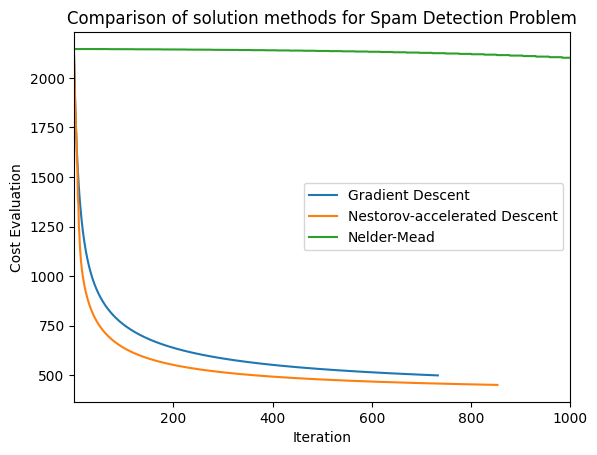

In [15]:
comparison_plot(1000)

Zooming in one last time, we notice that the first few iterations of NAGD are a bit jagged. This is possibly related to the
some initial transience in the nestorov acceleration constant which is uses a memory of previous points to extrapolate.


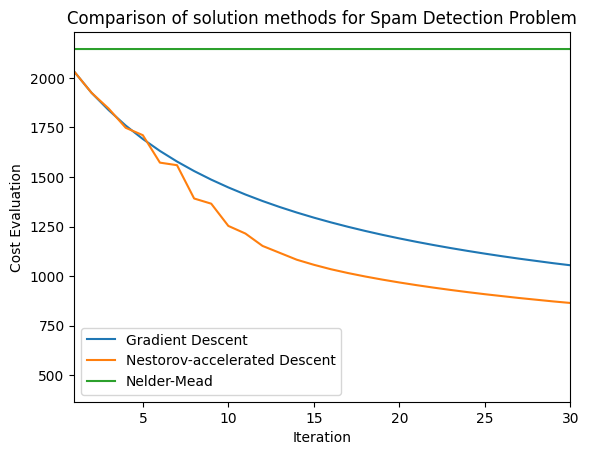

In [16]:
comparison_plot(30)

# Problem 2

We now implement a a L1 norm cost function and its proximity operator. We verify that it works properly on a simple test case.

## Testing and validation
Test that nonsmooth functions can be optimized properly.


In [17]:
class L1Cost:
    def __init__(self, b=0, lambda_=1):
        self.b = b
        self.lambda_ = lambda_

    def g(self, x):
        return np.linalg.norm(x - self.b, ord=1)

    def prox(self, t, y):
        # Shift by b
        y = y - self.b
        return self.b + np.sign(y) * np.maximum(np.abs(y) - t * self.lambda_, 0)
        
        

        

In [24]:
y = np.linspace(-20, 20, 1000)
c = L1Cost(np.array([1, 2, 3, 4]))
# c = L1Cost(np.zeros(4))
res = prox_gradient_descent(ZeroCost(), x0=np.ones(4), nonsmooth_cost = c, stepsize=10)
print(res)
res.f = c.g

SolverResult:
    Converged=True
    iterations=3
    function_eval=0.0



Notice that it converges to the exact solution after a single iteration when the step size is large enough, effectively projecting to a point.

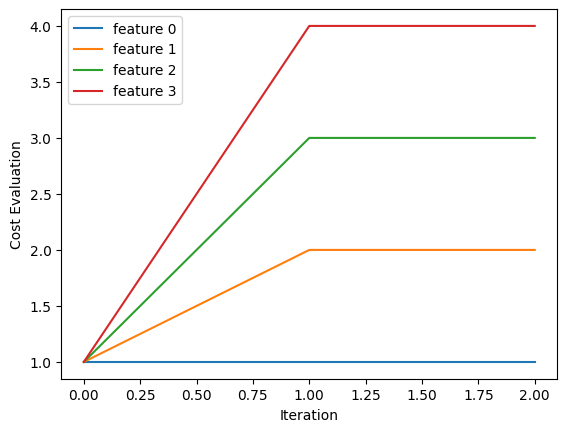

In [27]:
res.plot_solution(4)

Now, we add the L1 cost in and compare with a couple different values of lambda.

## Running Optimizer with varying Regularization Constants

In [33]:
reg_opts = {**options, 'nonsmooth_cost': L1Cost(lambda_=5)}
m_reg = Model(LL, prox_gradient_descent, solver_options=reg_opts)

In [34]:
high_reg_opts = {**options, 'nonsmooth_cost': L1Cost(lambda_=100)}
m_high_reg = Model(LL, prox_gradient_descent, solver_options=high_reg_opts)

In [37]:
m_reg.train(dataset)
print("Lambda = 5")
print(m_reg.result)
m_high_reg.train(dataset)
print("Lambda = 100")
print(m_high_reg.result)

Lambda = 5
SolverResult:
    Converged=True
    iterations=669
    function_eval=486.4455988616261

Lambda = 100
SolverResult:
    Converged=True
    iterations=275
    function_eval=758.6086757177875



## Plots and Discussion
A plot of the objective function over iteration is shown below. We see that as expected, the regularized cost is higher in magnitude than the cost for the unregularilized objective function (since we are adding a nonnegative quantity. Interestingly, the Nestorov acceleration still allows the `lambda=5` regularized problem to converge to a better solution (for a constant tolerance difference between iterations). When the regularization constant is increased up to 100, however, this term dominates and causes it to terminate at a much greater objective value.


In [44]:
all_models = [m, m_accel, m_reg, m_high_reg]
all_model_names = ["Gradient Descent", "Nestorov-accelerated Descent", 
              "Regularized (lambda=5)", "Regularized (lambda=100)"]

(1.0, 1000.0)

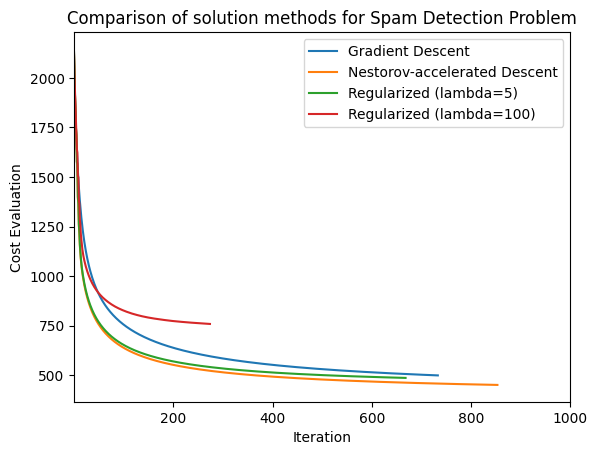

In [45]:
plt.figure()
for model, label in zip(all_models, all_model_names):
    plt.plot(model.result.costs, label=label)
plt.legend()

plt.xlabel("Iteration")
plt.ylabel("Cost Evaluation")
plt.title("Comparison of solution methods for Spam Detection Problem")
# plt.xlim([0, 30])
plt.xlim([1, 1000])

## Comparison Feature vectors
Below, we utilize code from the previous HW's solutions to visualize the feature vectors. We see that the L1 term entirely surpresses the features weakly represented in the unregularized case. This affect is particularly acute when the regularization constant is set to 100, with only a select few features achieving non-zero values. This indicates that the non-smoothness of the regularization cost encourages sparsity.


In [54]:
from cvx_opt.hw6 import plot_features

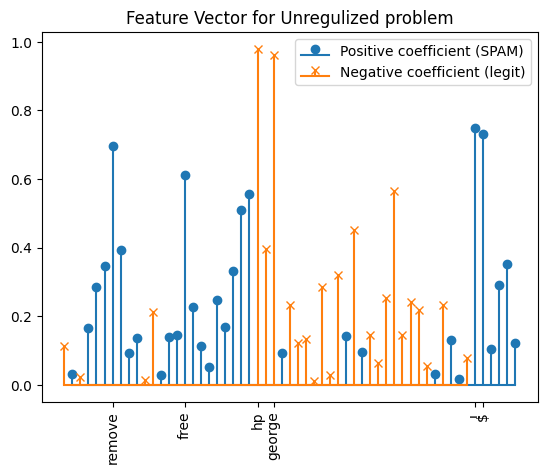

In [55]:
plt.title("Feature Vector for Unregulized problem")
plot_features(m_accel.w)

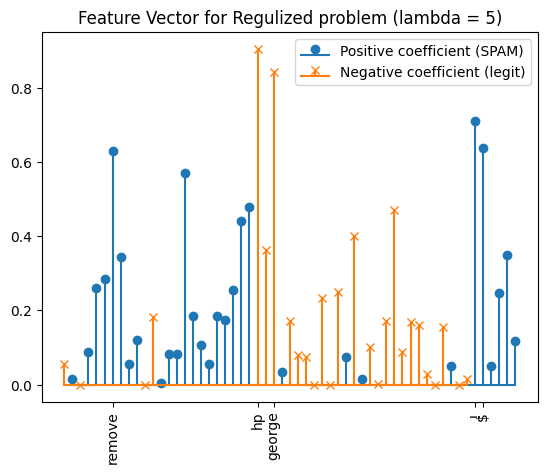

In [56]:
plt.title("Feature Vector for Regulized problem (lambda = 5)")
plot_features(m_reg.w)

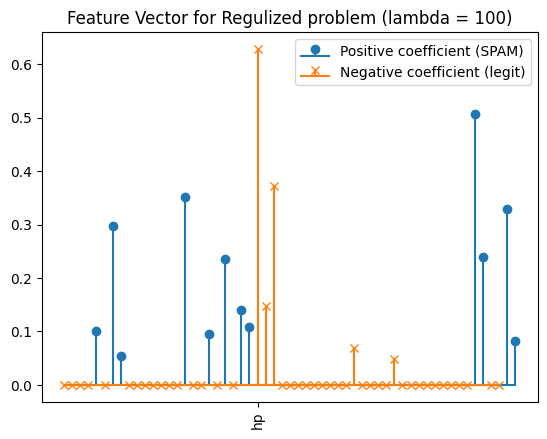

In [58]:
plt.title("Feature Vector for Regulized problem (lambda = 100)")
plot_features(m_high_reg.w)

Below are a copmarison of the training and testing success rates for the different optimization formulations. Interestingly, we don't see a meaningful improvement to the generalizability of the model as we add regularization. Especially for the high regulization case, the difference between the testing and training values is the greatest, achieving only 78% classification success. This further demonstrates how L1 regulization encourages the model to use a sparser set of parameters, rather than generalization to unseen cases.

In [59]:
for model, name in zip(all_models, all_model_names):
    print(name)
    print("Validation cost:", model.validate(dataset))
    print("training success (%):", 100 * model.classification_rate(dataset, training=True))
    print("testing success (%):", 100 * model.classification_rate(dataset, training=False))
    print()

Gradient Descent
Validation cost: 544.1453652600097
training success (%): 94.89664082687338
testing success (%): 84.31893687707641

Nestorov-accelerated Descent
Validation cost: 535.1411162038698
training success (%): 95.34883720930233
testing success (%): 85.38205980066445

Regularized (lambda=5)
Validation cost: 537.7277056543919
training success (%): 95.12273901808786
testing success (%): 85.11627906976744

Regularized (lambda=100)
Validation cost: 654.9760737114141
training success (%): 92.24806201550388
testing success (%): 78.40531561461795



# Problem 3

While you might think that the CVXPY code would be simpler than the code we wrote for previous problem, we actually went to a bit of length here in a debugging attempt. See the cropping section below for a full bug report: it seems that CVXPY doesn't handle sparse matrices all that well after all.

## Extract Image and preprocess
The code below load from a png and converts from an unsigned 16-bit integer to a matrix of floats between 0 and 1. We then add noise, as prescribed in the assignment

In [60]:
import numpy as np
from cvx_opt.hw6 import DATA_DIR
from PIL import Image

In [61]:
png_filename = DATA_DIR / "SheppLogan_150x150.png"

In [62]:
UINT16_MAX = 2 ** 16 - 1

def to_float(uint16):
    return uint16.astype(np.float64) / UINT16_MAX

def to_uint16(float64):
    return (float64 * UINT16_MAX).astype(np.uint16)

In [63]:
def img_to_array(img):
    return to_float(np.array(img))

def array_to_img(arr):
    return Image.fromarray(to_uint16(arr))

In [64]:
def add_noise(X):
    np.random.seed(0)
    mask = np.random.uniform(0, 1, X.shape) < 0.1
    Y = X.copy()
    noise = np.random.uniform(0, 1, X.shape)
    Y[mask] += noise[mask]
    return np.minimum(Y, 1)
    

In [65]:
img = Image.open(png_filename)
X_orig = img_to_array(img)
Y = add_noise(X_orig)

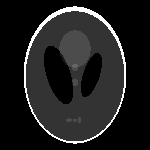

In [66]:
array_to_img(X_orig)

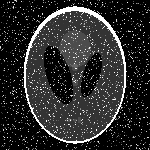

In [67]:
array_to_img(Y)

In [68]:
import cvxpy as cp

In [69]:
import scipy.sparse as sp

In [70]:
def dense_spdiags(data, diags, n1, n2):
    """ Mimics spdiags but returns a dense matrix """
    D = np.zeros((n1, n2))
    for d, diag_data in zip(diags, data):
        np.fill_diagonal(D[max(0, -d):, max(0, d):], diag_data)
    return D

data = np.array([[1, 2, 3], [4, 5, 6]])  # Rows correspond to diagonals
diags = [-1, 1]  # Subdiagonal (-1) and superdiagonal (1)

D = dense_spdiags(data, diags, 4, 4)
print(D)

[[0. 4. 0. 0.]
 [1. 0. 5. 0.]
 [0. 2. 0. 6.]
 [0. 0. 3. 0.]]


## Visually check differential operator

In [ ]:
def diff_operator(n, sparse=True):
    diags = sp.spdiags if sparse else dense_spdiags
    return diags([np.ones(n), -np.ones(n)], [0, 1], n, n)

In [105]:
diff_operator(5).toarray()

array([[ 1., -1.,  0.,  0.,  0.],
       [ 0.,  1., -1.,  0.,  0.],
       [ 0.,  0.,  1., -1.,  0.],
       [ 0.,  0.,  0.,  1., -1.],
       [ 0.,  0.,  0.,  0.,  1.]])

In [106]:
diff_operator(5, sparse=False)

array([[ 1., -1.,  0.,  0.,  0.],
       [ 0.,  1., -1.,  0.,  0.],
       [ 0.,  0.,  1., -1.,  0.],
       [ 0.,  0.,  0.,  1., -1.],
       [ 0.,  0.,  0.,  0.,  1.]])

## Crop the image to limit problem size

In [107]:
# N_img = 150
# We crop the image here since there seems to be a bug inside CVXPY!!!
# For N_img>=110, we have the following error when solving:
#
#     File ~/Library/Application Support/hatch/env/virtual/cvx-opt/TUZEwH1z/cvx-opt/lib/python3.12/site-packages/cvxpy/reductions/solvers/conic_solvers/conic_solver.py:273, in ConicSolver.format_constraints(self, problem, exp_cone_order)
#         271     restructured_A.row = restructured_A.row.astype(np.int64)
#         272     restructured_A.col = restructured_A.col.astype(np.int64)
#     --> 273     restructured_A = restructured_A.reshape(
#         274         np.int64(restruct_mat.shape[0]) * (np.int64(problem.x.size) + 1),
#         275         problem.A.shape[1], order='F')
#         276 else:
#         277     restructured_A = problem.A
#     
#     File ~/Library/Application Support/hatch/env/virtual/cvx-opt/TUZEwH1z/cvx-opt/lib/python3.12/site-packages/scipy/sparse/_coo.py:161, in _coo_base.reshape(self, *args, **kwargs)
#         158 else:
#         159     new_data = self.data
#     --> 161 return self.__class__((new_data, new_coords), shape=shape, copy=False)
#     
#     File ~/Library/Application Support/hatch/env/virtual/cvx-opt/TUZEwH1z/cvx-opt/lib/python3.12/site-packages/scipy/sparse/_coo.py:101, in _coo_base.__init__(self, arg1, shape, dtype, copy, maxprint)
#          98 if len(self._shape) > 2:
#          99     self.coords = tuple(idx.astype(np.int64, copy=False) for idx in self.coords)
#     --> 101 self._check()
#     
#     File ~/Library/Application Support/hatch/env/virtual/cvx-opt/TUZEwH1z/cvx-opt/lib/python3.12/site-packages/scipy/sparse/_coo.py:225, in _coo_base._check(self)
#         222     raise ValueError(f'axis {i} index {idx.max()} exceeds '
#         223                      f'matrix dimension {self.shape[i]}')
#         224 if idx.min() < 0:
#     --> 225     raise ValueError(f'negative axis {i} index: {idx.min()}')
#     
#     ValueError: negative axis 0 index: -2147467360
# 
#
# I even tried to replace all the sparse inputs with dense ones. It seems that internally, as CVXPY reduces and restructures
# the problem to a canonical form, it is using sparse matrices. The integer indices must be overflowing...
# You can check the sparse matrices that are created below: e.g. L.indices.min(). None of the matrices we are creating
# are causing this directly, but rather CVXPY is building (much) larger matrices as the problem is restructured.
N_img = 100
Y = Y[:N_img, :N_img]
X_orig = X_orig[:N_img, :N_img]

In [76]:
def vec(X):
    return X.flatten(order="F")

def mat(x):
    return x.reshape((N_img, N_img), order="F")

In [77]:
assert np.allclose(Y, mat(vec(Y)))

## 2D Differential Operator

In [78]:
def L_operator(n_1, n_2):
    """
    Return a complex matrix representing the 1st order dicrete difference
    across horizontal (real) and vertical (imaginary) axes.
    """
    L_h = sp.kron(diff_operator(n_2), sp.eye(n_1))
    L_v = sp.kron(sp.eye(n_2), diff_operator(n_1))
    return L_h + 1j * L_v
    

L = L_operator(N_img, N_img)

In [79]:
def L_operators(n_1, n_2, sparse=True):
    # Breakdown the complex-valued linear operator into a tuple of real-valued ones.
    # (Another attempt to fix CVXPY indexing.)
    mod = sp if sparse else np
    L_h = mod.kron(diff_operator(n_2, sparse=sparse), mod.eye(n_1))
    L_v = mod.kron(mod.eye(n_2), diff_operator(n_1, sparse=sparse))
    return L_h, L_v
    


In [80]:
L_h, L_v = L_operators(N_img, N_img, sparse=True)

In [81]:
# diffs = mat(L @ vec(X_orig))
diffs = mat(L_h @ vec(X_orig)) + 1j * mat(L_v @ vec(X_orig))

In [83]:
# Checking that the differential operator L works as one might expect

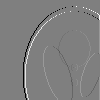

In [84]:
array_to_img((np.real(diffs) + 1) / 2)

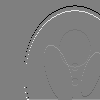

In [85]:
array_to_img((np.imag(diffs) + 1) / 2)

## TV implementation

In [ ]:
def TV(X):
    # The complex 
    return cp.norm(L @ vec(X), p=1)

In [87]:
def TV_real(X):
    x = vec(X)
    diff_h = L_h @ x
    diff_v = L_v @ x
    diff = cp.vstack([diff_h, diff_v])
    return cp.norm(
        cp.norm(diff, axis=0, p=2),
        p=1
    )
        
    # diff = cp.sqrt(diff_h ** 2 + diff_v ** 2)
    # return cp.norm(diff, p=1)

In [88]:
# Quick check on complex norm logic...
# Each complex modulus is sqrt(2) and 1-norm takes the sum.
n = 5
x = np.full(5, 1 + 1j)
assert(np.isclose(np.linalg.norm(x, ord=1), n * np.sqrt(2)))

In [89]:
print("TV of original image:", TV(X_orig).value)
print("TV of noisy image:", TV(Y).value)

TV of original image: 380.13602125201703
TV of noisy image: 1903.853580483822


In [90]:
# Check that complex and real-valued operators agree.
print("TV of original image:", TV_real(X_orig).value)
print("TV of noisy image:", TV_real(Y).value)

TV of original image: 380.13602125201703
TV of noisy image: 1903.853580483822


In [91]:
tau = 1/4 * TV(Y).value
print("Tau =", tau)

Tau = 475.9633951209555


In [92]:
X = cp.Variable((N_img, N_img))
# y = cp.Constant(Y)
objective = 1/2 * cp.norm(X - Y, p="fro") ** 2
constraints = [
    TV_real(X) <= tau
]
prob = cp.Problem(cp.Minimize(objective), constraints)
result = prob.solve(verbose=True, solver=cp.SCS)

                                     CVXPY                                     
                                     v1.5.4                                    
(CVXPY) Mar 15 05:45:31 AM: Your problem has 10000 variables, 1 constraints, and 0 parameters.
(CVXPY) Mar 15 05:45:31 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 15 05:45:31 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 15 05:45:31 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 15 05:45:31 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 15 05:45:31 AM: Compiling problem (target solver=SCS).
(C

In [96]:
result

np.float64(107.56603209029439)

## Comparison of Noisy and Denoised Image

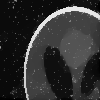

In [103]:
array_to_img(mat(X.value))

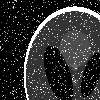

In [102]:
array_to_img(mat(Y))